# Preparação dos Dados — Setor de Software OCDE (J62+J63)

Este notebook realiza a preparação completa dos dados estruturais da OCDE para uso no sistema de **Market Twin** e **predição de trajetória de mercado de software**.

As etapas realizadas são:

1. Carregamento e inspeção inicial
2. Limpeza de dados — NaN, tipos, duplicatas
3. Remoção de países com cobertura insuficiente
4. Análise e tratamento de outliers
5. Feature engineering — métricas derivadas, interpolação e normalização
6. Exportação do dataset final

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.edgecolor':     '#cccccc',
    'axes.labelcolor':    '#333333',
    'axes.titlecolor':    '#111111',
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#eeeeee',
    'grid.linewidth':     0.8,
    'xtick.color':        '#666666',
    'ytick.color':        '#666666',
    'text.color':         '#333333',
    'legend.facecolor':   'white',
    'legend.edgecolor':   '#dddddd',
    'legend.fontsize':    9,
})

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## 1. Carregamento e Inspeção Inicial

In [2]:
df_raw = pd.read_csv('dados_ocde_software.csv')

print(f'Shape: {df_raw.shape}')
print(f'Colunas: {df_raw.columns.tolist()}')
print(f'\nPaíses únicos: {df_raw["Pais"].nunique()}')
print(f'Anos: {sorted(df_raw["Ano"].unique())}')
print(f'Setores: {df_raw["Setor"].unique().tolist()}')
df_raw.head(10)

Shape: (1020, 6)
Colunas: ['Pais', 'Setor', 'Ano', 'EMPE', 'ENTR', 'TUTT']

Países únicos: 43
Anos: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Setores: ['J62', 'J63']


,Pais,Setor,Ano,EMPE,ENTR,TUTT
0,ALB,J62,2019,4549.0,1167.0,15646.872070
1,ALB,J62,2020,4771.0,1442.0,18850.169922
2,ALB,J63,2019,912.0,445.0,2226.481201
3,ALB,J63,2020,1654.0,424.0,2958.102783
4,ALB,J63,2021,1798.0,291.0,4411.009277
5,ALB,J63,2022,2109.0,427.0,6747.355957
6,AUT,J62,2010,29315.0,8940.0,4927.700195
7,AUT,J62,2011,32070.0,9363.0,5808.399902
8,AUT,J62,2012,34409.0,9650.0,6372.299805
9,AUT,J62,2013,36421.0,9964.0,7091.100098


In [3]:
print('--- Tipos ---')
print(df_raw.dtypes)
print('\n--- Valores ausentes ---')
print(df_raw.isnull().sum())
print('\n--- Estatísticas descritivas ---')
df_raw.describe()

--- Tipos ---
Pais      object
Setor     object
Ano        int64
EMPE     float64
ENTR     float64
TUTT     float64
dtype: object

--- Valores ausentes ---
Pais      0
Setor     0
Ano       0
EMPE     92
ENTR     30
TUTT     53
dtype: int64

--- Estatísticas descritivas ---


,Ano,EMPE,ENTR,TUTT
count,1020.000000,9.280000e+02,990.000000,9.670000e+02
mean,2016.032353,7.245766e+04,13483.789899,6.002224e+05
std,3.697854,1.706237e+05,24358.823697,3.791661e+06
min,2010.000000,0.000000e+00,0.000000,0.000000e+00
25%,2013.000000,5.696750e+03,1035.000000,7.972871e+02
50%,2016.000000,1.598750e+04,4383.500000,7.206472e+03
75%,2019.000000,6.431200e+04,11755.250000,3.824445e+04
max,2022.000000,1.750961e+06,167506.000000,4.740806e+07


---
## 2. Limpeza de Dados

In [4]:
df = df_raw.copy()

# 2.1 Garantir tipos corretos
df['Ano']  = pd.to_numeric(df['Ano'],  errors='coerce')
df['ENTR'] = pd.to_numeric(df['ENTR'], errors='coerce')
df['TUTT'] = pd.to_numeric(df['TUTT'], errors='coerce')
df['EMPE'] = pd.to_numeric(df['EMPE'], errors='coerce')

# 2.2 Remover duplicatas exatas
n_antes = len(df)
df = df.drop_duplicates(subset=['Pais', 'Setor', 'Ano'])
print(f'Duplicatas removidas: {n_antes - len(df)}')

# 2.3 Agregar J62+J63 por pais+ano
# min_count=1: retorna NaN apenas se AMBOS os setores forem nulos
df = (
    df.groupby(['Pais', 'Ano'], as_index=False)[['ENTR', 'TUTT', 'EMPE']]
    .sum(min_count=1)
)

print(f'Shape após agregação J62+J63: {df.shape}')
print(f'Países: {df["Pais"].nunique()}')
df.head(10)

Duplicatas removidas: 0
Shape após agregação J62+J63: (511, 5)
Países: 43


,Pais,Ano,ENTR,TUTT,EMPE
0,ALB,2019,1612.0,17873.353271,5461.0
1,ALB,2020,1866.0,21808.272705,6425.0
2,ALB,2021,291.0,4411.009277,1798.0
3,ALB,2022,427.0,6747.355957,2109.0
4,AUT,2010,12849.0,7355.600098,41793.0
5,AUT,2011,13227.0,8683.399902,45761.0
6,AUT,2012,13545.0,9283.199707,48444.0
7,AUT,2013,13863.0,10036.300049,50439.0
8,AUT,2014,14236.0,10808.200195,53606.0
9,AUT,2015,14387.0,10953.200195,54297.0


---
## 3. Remoção de Países com Cobertura Insuficiente

Países com série muito incompleta não contribuem para a análise de twins por trajetória.
O critério adotado é: **mínimo de 60% dos anos com valor não-nulo em ENTR**.

Países removidos aqui não são outliers — são casos sem dados suficientes para comparação.

Limite de cobertura: 60.0%
Países removidos (5): ['COL', 'KOR', 'ALB', 'USA', 'SRB']
Países mantidos: 38


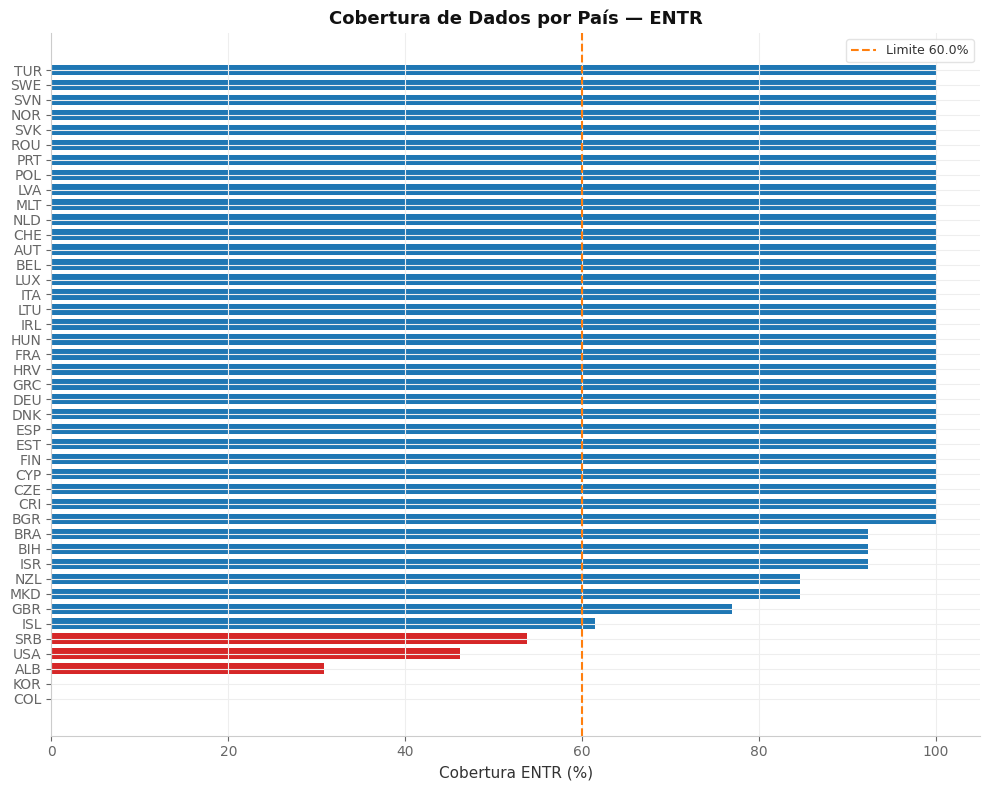


Shape após filtro de cobertura: (480, 5)


In [5]:
n_anos_total = df['Ano'].nunique()

cobertura = (
    df.groupby('Pais')['ENTR']
    .apply(lambda s: s.notna().sum() / n_anos_total)
    .sort_values()
    .mul(100)
    .round(1)
    .rename('Cobertura_ENTR_Pct')
    .reset_index()
)

LIMITE_COBERTURA = 60.0
paises_removidos = cobertura[cobertura['Cobertura_ENTR_Pct'] < LIMITE_COBERTURA]['Pais'].tolist()
paises_mantidos  = cobertura[cobertura['Cobertura_ENTR_Pct'] >= LIMITE_COBERTURA]['Pais'].tolist()

print(f'Limite de cobertura: {LIMITE_COBERTURA}%')
print(f'Países removidos ({len(paises_removidos)}): {paises_removidos}')
print(f'Países mantidos: {len(paises_mantidos)}')

fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#d62728' if c < LIMITE_COBERTURA else '#1f77b4' for c in cobertura['Cobertura_ENTR_Pct']]
ax.barh(cobertura['Pais'], cobertura['Cobertura_ENTR_Pct'], color=cores, height=0.7)
ax.axvline(LIMITE_COBERTURA, color='#ff7f0e', linewidth=1.5, linestyle='--', label=f'Limite {LIMITE_COBERTURA}%')
ax.set_xlabel('Cobertura ENTR (%)')
ax.set_title('Cobertura de Dados por País — ENTR')
ax.legend()
plt.tight_layout()
plt.show()

df = df[df['Pais'].isin(paises_mantidos)].copy()
print(f'\nShape após filtro de cobertura: {df.shape}')

---
## 4. Análise e Tratamento de Outliers

### Critério de decisão

Para este dataset, **outliers estruturais são preservados**:

- Países como França (FRA) e Alemanha (DEU) têm valores altos porque seus mercados são grandes — isso é realidade, não erro.
- São as âncoras do modelo de twins: trajetórias que mercados menores tendem a seguir.
- O tratamento correto para escala é **normalização**, não remoção.

Investigamos três categorias:
1. Outliers de escala absoluta (ENTR, TUTT, EMPE) → manter, normalizar depois
2. Outliers de produtividade (TUTT/EMPE) → manter com flag
3. Valores impossíveis (≤ 0 em ENTR ou EMPE) → remover

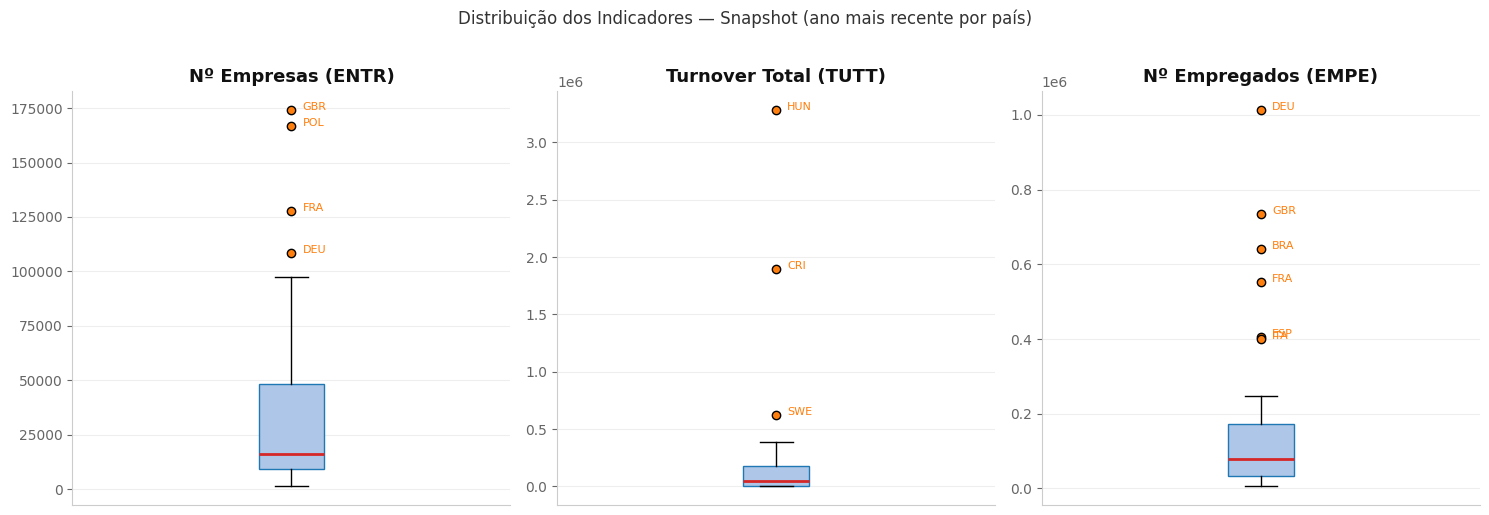

In [6]:
# Snapshot: ano mais recente disponivel por pais
df_snapshot = (
    df.dropna(subset=['ENTR', 'TUTT', 'EMPE'])
    .sort_values('Ano')
    .groupby('Pais')
    .last()
    .reset_index()
)

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
indicadores = ['ENTR', 'TUTT', 'EMPE']
labels      = ['Nº Empresas (ENTR)', 'Turnover Total (TUTT)', 'Nº Empregados (EMPE)']

for ax, col, label in zip(axes, indicadores, labels):
    ax.boxplot(df_snapshot[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#ff7f0e', markersize=6))
    q1, q3 = df_snapshot[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df_snapshot[
        (df_snapshot[col] < q1 - 1.5 * iqr) | (df_snapshot[col] > q3 + 1.5 * iqr)
    ]
    for _, row in outliers.iterrows():
        ax.annotate(row['Pais'], (1, row[col]), textcoords='offset points',
                    xytext=(8, 0), fontsize=8, color='#ff7f0e')
    ax.set_title(label)
    ax.set_xticks([])

fig.suptitle('Distribuição dos Indicadores — Snapshot (ano mais recente por país)', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
def identificar_outliers_iqr(df_snap: pd.DataFrame, col: str) -> pd.DataFrame:
    q1  = df_snap[col].quantile(0.25)
    q3  = df_snap[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    out = df_snap[(df_snap[col] < lim_inf) | (df_snap[col] > lim_sup)][['Pais', col]].copy()
    out['Limite_Inf'] = round(lim_inf, 1)
    out['Limite_Sup'] = round(lim_sup, 1)
    out['Tipo'] = out[col].apply(lambda v: 'Superior' if v > lim_sup else 'Inferior')
    return out

for col in ['ENTR', 'TUTT', 'EMPE']:
    out = identificar_outliers_iqr(df_snapshot, col)
    print(f'\n--- Outliers IQR — {col} ---')
    print('Nenhum outlier identificado.' if out.empty else out.to_string(index=False))


--- Outliers IQR — ENTR ---
Pais     ENTR  Limite_Inf  Limite_Sup     Tipo
 DEU 108665.0    -48985.0    106587.0 Superior
 FRA 127612.0    -48985.0    106587.0 Superior
 GBR 174258.0    -48985.0    106587.0 Superior
 POL 166695.0    -48985.0    106587.0 Superior

--- Outliers IQR — TUTT ---
Pais         TUTT  Limite_Inf  Limite_Sup     Tipo
 CRI 1.894442e+06   -254322.2    437125.2 Superior
 HUN 3.284919e+06   -254322.2    437125.2 Superior
 SWE 6.202254e+05   -254322.2    437125.2 Superior

--- Outliers IQR — EMPE ---
Pais      EMPE  Limite_Inf  Limite_Sup     Tipo
 BRA  642081.0   -178126.2    382959.8 Superior
 DEU 1014270.0   -178126.2    382959.8 Superior
 ESP  406593.0   -178126.2    382959.8 Superior
 FRA  553796.0   -178126.2    382959.8 Superior
 GBR  735622.0   -178126.2    382959.8 Superior
 ITA  400111.0   -178126.2    382959.8 Superior


--- Outliers IQR — Produtividade (TUTT/EMPE) ---
Pais      PROD  Limite_Inf  Limite_Sup     Tipo
 CRI 47.795899        -1.6         3.0 Superior
 CZE  3.982708        -1.6         3.0 Superior
 HUN 39.554458        -1.6         3.0 Superior
 ISL 33.697172        -1.6         3.0 Superior
 SWE  3.620443        -1.6         3.0 Superior


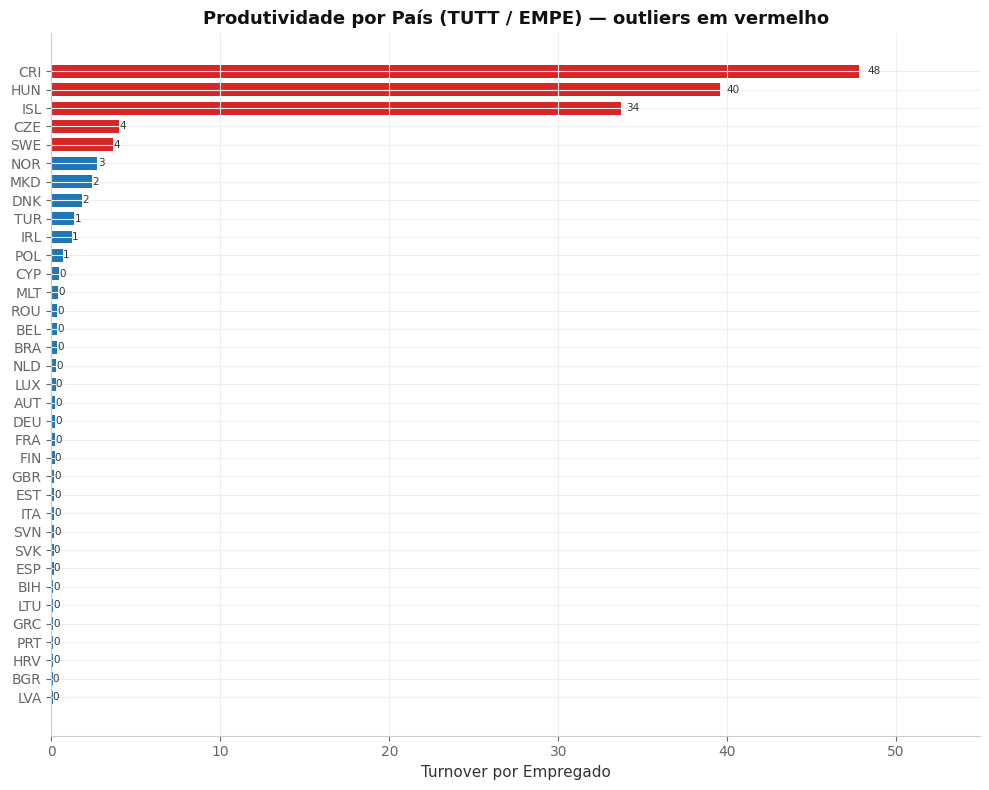

In [8]:
# Outliers de produtividade
df_snapshot['PROD'] = df_snapshot['TUTT'] / df_snapshot['EMPE']
out_prod = identificar_outliers_iqr(df_snapshot, 'PROD')

print('--- Outliers IQR — Produtividade (TUTT/EMPE) ---')
print('Nenhum outlier identificado.' if out_prod.empty else out_prod.to_string(index=False))

df_prod_ord = df_snapshot.dropna(subset=['PROD']).sort_values('PROD', ascending=True)
outliers_prod = out_prod['Pais'].tolist() if not out_prod.empty else []

fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#d62728' if p in outliers_prod else '#1f77b4' for p in df_prod_ord['Pais']]
bars = ax.barh(df_prod_ord['Pais'], df_prod_ord['PROD'], color=cores, height=0.7)
for bar, val in zip(bars, df_prod_ord['PROD']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=7.5)
ax.set_xlabel('Turnover por Empregado')
ax.set_title('Produtividade por País (TUTT / EMPE) — outliers em vermelho')
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

In [9]:
# Remover valores inviaveis
n_antes = len(df)
df = df[~((df['ENTR'] <= 0) | (df['EMPE'] <= 0))].copy()
print(f'Linhas removidas por valores inviáveis (<=0): {n_antes - len(df)}')

# Flag de outlier de produtividade
if not out_prod.empty:
    paises_outlier_prod = out_prod['Pais'].tolist()
    df['Flag_Outlier_Prod'] = df['Pais'].isin(paises_outlier_prod).astype(int)
    print(f'Países com flag de outlier de produtividade: {paises_outlier_prod}')
else:
    df['Flag_Outlier_Prod'] = 0

print(f'Shape após tratamento de outliers: {df.shape}')

Linhas removidas por valores inviáveis (<=0): 0
Países com flag de outlier de produtividade: ['CRI', 'CZE', 'HUN', 'ISL', 'SWE']
Shape após tratamento de outliers: (480, 6)


---
## 5. Feature Engineering

### 5.1 Métricas derivadas
- `PROD` — produtividade (TUTT / EMPE)
- `TAMANHO_MEDIO` — tamanho médio das empresas (EMPE / ENTR)

### 5.2 Interpolação
Interpolação linear por país, limitada a 2 anos consecutivos.

### 5.3 Normalização — StandardScaler por coluna

A normalização é aplicada **coluna por coluna**, com um `StandardScaler` independente para cada indicador.
Isso garante que:
- Cada coluna tenha média 0 e desvio padrão 1 **calculados apenas sobre os valores não-nulos**
- NaN restantes são preservados (não participam do fit nem são imputados)
- A escala relativa entre países é mantida dentro de cada indicador

A abordagem anterior usava uma única máscara sobre todas as colunas simultaneamente,
o que excluía do fit qualquer linha com NaN em *qualquer* coluna — mesmo que aquela
coluna específica tivesse valor válido. Isso produzia médias e desvios incorretos.

In [10]:
# 5.1 Metricas derivadas
df['PROD']          = df['TUTT'] / df['EMPE']
df['TAMANHO_MEDIO'] = df['EMPE'] / df['ENTR']

print('Métricas derivadas criadas: PROD, TAMANHO_MEDIO')
print(f'NaN em PROD:          {df["PROD"].isna().sum()}')
print(f'NaN em TAMANHO_MEDIO: {df["TAMANHO_MEDIO"].isna().sum()}')

Métricas derivadas criadas: PROD, TAMANHO_MEDIO
NaN em PROD:          44
NaN em TAMANHO_MEDIO: 32


In [11]:
# 5.2 Interpolacao linear por pais
COLUNAS_INTERPOLACAO = ['ENTR', 'TUTT', 'EMPE', 'PROD', 'TAMANHO_MEDIO']

nan_antes = df[COLUNAS_INTERPOLACAO].isna().sum()

df = df.sort_values(['Pais', 'Ano'])
df[COLUNAS_INTERPOLACAO] = (
    df.groupby('Pais')[COLUNAS_INTERPOLACAO]
    .transform(lambda s: s.interpolate(method='linear', limit=2, limit_direction='both'))
)

nan_depois = df[COLUNAS_INTERPOLACAO].isna().sum()

comparacao = pd.DataFrame({
    'Antes':       nan_antes,
    'Depois':      nan_depois,
    'Preenchidos': nan_antes - nan_depois
})
print('--- NaN antes vs. depois da interpolação ---')
print(comparacao.to_string())
print(f'\nNaN restantes (gaps > 2 anos — mantidos): {df[COLUNAS_INTERPOLACAO].isna().sum().sum()}')

--- NaN antes vs. depois da interpolação ---
               Antes  Depois  Preenchidos
ENTR               1       0            1
TUTT              19      15            4
EMPE              32      25            7
PROD              44      37            7
TAMANHO_MEDIO     32      25            7

NaN restantes (gaps > 2 anos — mantidos): 102


In [12]:
# 5.3 Normalizacao: StandardScaler por coluna individualmente
# Cada coluna tem seu proprio scaler — fit apenas nos valores nao-nulos da coluna
# NaN sao preservados e nao participam do calculo de media/desvio

COLUNAS_NORMALIZAR = ['ENTR', 'TUTT', 'EMPE', 'PROD', 'TAMANHO_MEDIO']

df_scaled = df.copy()
scalers   = {}   # guarda os scalers para uso futuro (inverter transformacao se necessario)

for col in COLUNAS_NORMALIZAR:
    mask = df_scaled[col].notna()
    scaler = StandardScaler()
    df_scaled.loc[mask, col] = scaler.fit_transform(
        df_scaled.loc[mask, col].values.reshape(-1, 1)
    ).flatten()
    scalers[col] = scaler

print('Normalização concluída — StandardScaler por coluna.')
print('\n--- Médias após normalização (esperado: ~0) ---')
print(df_scaled[COLUNAS_NORMALIZAR].mean().round(6).to_string())
print('\n--- Desvios padrão após normalização (esperado: ~1) ---')
print(df_scaled[COLUNAS_NORMALIZAR].std().round(6).to_string())
print('\n--- NaN preservados ---')
print(df_scaled[COLUNAS_NORMALIZAR].isna().sum().to_string())

Normalização concluída — StandardScaler por coluna.

--- Médias após normalização (esperado: ~0) ---
ENTR            -0.0
TUTT             0.0
EMPE             0.0
PROD            -0.0
TAMANHO_MEDIO   -0.0

--- Desvios padrão após normalização (esperado: ~1) ---
ENTR             1.001043
TUTT             1.001077
EMPE             1.001101
PROD             1.001131
TAMANHO_MEDIO    1.001101

--- NaN preservados ---
ENTR              0
TUTT             15
EMPE             25
PROD             37
TAMANHO_MEDIO    25


---
## 6. Validação Final e Exportação

In [13]:
print('=== Dataset Final (valores originais + derivadas) ===')
print(f'Shape:   {df.shape}')
print(f'Países:  {df["Pais"].nunique()}')
print(f'Anos:    {sorted(df["Ano"].unique())}')
print(f'Colunas: {df.columns.tolist()}')
print(f'\nNaN restantes:')
print(df.isnull().sum().to_string())
df.head(10)

=== Dataset Final (valores originais + derivadas) ===
Shape:   (480, 8)
Países:  38
Anos:    [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Colunas: ['Pais', 'Ano', 'ENTR', 'TUTT', 'EMPE', 'Flag_Outlier_Prod', 'PROD', 'TAMANHO_MEDIO']

NaN restantes:
Pais                  0
Ano                   0
ENTR                  0
TUTT                 15
EMPE                 25
Flag_Outlier_Prod     0
PROD                 37
TAMANHO_MEDIO        25


,Pais,Ano,ENTR,TUTT,EMPE,Flag_Outlier_Prod,PROD,TAMANHO_MEDIO
4,AUT,2010,12849.0,7355.600098,41793.0,0,0.176001,3.252627
5,AUT,2011,13227.0,8683.399902,45761.0,0,0.189755,3.459666
6,AUT,2012,13545.0,9283.199707,48444.0,0,0.191627,3.576523
7,AUT,2013,13863.0,10036.300049,50439.0,0,0.198979,3.638390
8,AUT,2014,14236.0,10808.200195,53606.0,0,0.201623,3.765524
9,AUT,2015,14387.0,10953.200195,54297.0,0,0.201728,3.774032
10,AUT,2016,14405.0,11762.399902,57795.0,0,0.203519,4.012149
11,AUT,2017,15289.0,12598.899902,61702.0,0,0.204189,4.035712
12,AUT,2018,15376.0,13730.200195,63542.0,0,0.216081,4.132544
13,AUT,2019,16511.0,15501.600586,65389.0,0,0.237067,3.960329


In [14]:
print('=== Dataset Normalizado (para ML) ===')
print(f'Shape: {df_scaled.shape}')
df_scaled[COLUNAS_NORMALIZAR].describe().round(4)

=== Dataset Normalizado (para ML) ===
Shape: (480, 8)


,ENTR,TUTT,EMPE,PROD,TAMANHO_MEDIO
count,480.0000,465.0000,455.0000,443.0000,455.0000
mean,-0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.0010,1.0011,1.0011,1.0011,1.0011
min,-0.7672,-0.3407,-0.6803,-0.3407,-2.0831
25%,-0.6337,-0.3340,-0.5961,-0.3279,-0.8520
50%,-0.4485,-0.2847,-0.3812,-0.3173,-0.1204
75%,0.2589,-0.0989,0.0438,-0.2419,0.6975
max,4.3996,9.1252,5.0276,5.3280,2.7294


In [15]:
df.to_csv('dados_ocde_preparado.csv', index=False)
df_scaled.to_csv('dados_ocde_normalizado.csv', index=False)

print('Arquivos exportados:')
print('  dados_ocde_preparado.csv   — valores originais + derivadas')
print('  dados_ocde_normalizado.csv — valores normalizados para ML')

Arquivos exportados:
  dados_ocde_preparado.csv   — valores originais + derivadas
  dados_ocde_normalizado.csv — valores normalizados para ML


---
## Sumário das Decisões de Preparação

| Etapa | Decisão | Justificativa |
|-------|---------|---------------|
| Duplicatas | Removidas | Erro de ingestão |
| Agregação J62+J63 | Somados por país+ano | Análise é do setor combinado |
| Países < 60% cobertura | Removidos | Série insuficiente para trajetória |
| Outliers de escala (FRA, DEU…) | **Mantidos** | Âncoras do modelo de twins |
| Outliers de produtividade | **Mantidos com flag** | Explicação estrutural documentada |
| Valores ≤ 0 em ENTR/EMPE | Removidos | Erros de medição |
| NaN ≤ 2 anos consecutivos | Interpolação linear | Preserva série sem imputação excessiva |
| NaN > 2 anos consecutivos | Mantidos | Ausência real de reporte |
| Normalização | StandardScaler por coluna | Média ~0 e desvio ~1 por indicador, NaN preservados |